In [ ]:
pip install pandas numpy matplotlib seaborn scikit-learn

In [16]:
# ==========================================
# IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,label_binarize

from sklearn.linear_model import LogisticRegression,Lasso
from sklearn.ensemble import RandomForestClassifier

from sklearn.feature_selection import (
    SelectKBest,
    f_classif,
    RFE
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# ==========================================
# LOAD DATASET
# ==========================================

df = pd.read_csv(r"C:\Users\surya\Downloads\fetal_health (1).csv")

print(df.head())



   baseline value  accelerations  fetal_movement  uterine_contractions  \
0           120.0          0.000             0.0                 0.000   
1           132.0          0.006             0.0                 0.006   
2           133.0          0.003             0.0                 0.008   
3           134.0          0.003             0.0                 0.008   
4           132.0          0.007             0.0                 0.008   

   light_decelerations  severe_decelerations  prolongued_decelerations  \
0                0.000                   0.0                       0.0   
1                0.003                   0.0                       0.0   
2                0.003                   0.0                       0.0   
3                0.003                   0.0                       0.0   
4                0.000                   0.0                       0.0   

   abnormal_short_term_variability  mean_value_of_short_term_variability  \
0                             73.0

In [ ]:
df.columns


Index(['baseline value', 'accelerations', 'fetal_movement',
       'uterine_contractions', 'light_decelerations', 'severe_decelerations',
       'prolongued_decelerations', 'abnormal_short_term_variability',
       'mean_value_of_short_term_variability',
       'percentage_of_time_with_abnormal_long_term_variability',
       'mean_value_of_long_term_variability', 'histogram_width',
       'histogram_min', 'histogram_max', 'histogram_number_of_peaks',
       'histogram_number_of_zeroes', 'histogram_mode', 'histogram_mean',
       'histogram_median', 'histogram_variance', 'histogram_tendency',
       'fetal_health'],
      dtype='str')

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2126 non-null   float64
 1   accelerations                                           2126 non-null   float64
 2   fetal_movement                                          2126 non-null   float64
 3   uterine_contractions                                    2126 non-null   float64
 4   light_decelerations                                     2126 non-null   float64
 5   severe_decelerations                                    2126 non-null   float64
 6   prolongued_decelerations                                2126 non-null   float64
 7   abnormal_short_term_variability                         2126 non-null   float64
 8   mean_value_of_short_term_variability             

In [14]:
df.describe()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
count,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.00000,...,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000
mean,133.303857,0.003178,0.009481,0.004366,0.001889,0.000003,0.000159,46.990122,1.332785,9.84666,...,93.579492,164.025400,4.068203,0.323612,137.452023,134.610536,138.090310,18.808090,0.320320,1.304327
std,9.840844,0.003866,0.046666,0.002946,0.002960,0.000057,0.000590,17.192814,0.883241,18.39688,...,29.560212,17.944183,2.949386,0.706059,16.381289,15.593596,14.466589,28.977636,0.610829,0.614377
min,106.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,0.200000,0.00000,...,50.000000,122.000000,0.000000,0.000000,60.000000,73.000000,77.000000,0.000000,-1.000000,1.000000
25%,126.000000,0.000000,0.000000,0.002000,0.000000,0.000000,0.000000,32.000000,0.700000,0.00000,...,67.000000,152.000000,2.000000,0.000000,129.000000,125.000000,129.000000,2.000000,0.000000,1.000000
50%,133.000000,0.002000,0.000000,0.004000,0.000000,0.000000,0.000000,49.000000,1.200000,0.00000,...,93.000000,162.000000,3.000000,0.000000,139.000000,136.000000,139.000000,7.000000,0.000000,1.000000
75%,140.000000,0.006000,0.003000,0.007000,0.003000,0.000000,0.000000,61.000000,1.700000,11.00000,...,120.000000,174.000000,6.000000,0.000000,148.000000,145.000000,148.000000,24.000000,1.000000,1.000000
max,160.000000,0.019000,0.481000,0.015000,0.015000,0.001000,0.005000,87.000000,7.000000,91.00000,...,159.000000,238.000000,18.000000,10.000000,187.000000,182.000000,186.000000,269.000000,1.000000,3.000000


In [18]:
df.isnull().sum()

baseline value                                            0
accelerations                                             0
fetal_movement                                            0
uterine_contractions                                      0
light_decelerations                                       0
severe_decelerations                                      0
prolongued_decelerations                                  0
abnormal_short_term_variability                           0
mean_value_of_short_term_variability                      0
percentage_of_time_with_abnormal_long_term_variability    0
mean_value_of_long_term_variability                       0
histogram_width                                           0
histogram_min                                             0
histogram_max                                             0
histogram_number_of_peaks                                 0
histogram_number_of_zeroes                                0
histogram_mode                          

In [19]:
df.drop_duplicates()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.000,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.000,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.000,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.000,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.000,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2121,140.0,0.000,0.000,0.007,0.000,0.0,0.0,79.0,0.2,25.0,...,137.0,177.0,4.0,0.0,153.0,150.0,152.0,2.0,0.0,2.0
2122,140.0,0.001,0.000,0.007,0.000,0.0,0.0,78.0,0.4,22.0,...,103.0,169.0,6.0,0.0,152.0,148.0,151.0,3.0,1.0,2.0
2123,140.0,0.001,0.000,0.007,0.000,0.0,0.0,79.0,0.4,20.0,...,103.0,170.0,5.0,0.0,153.0,148.0,152.0,4.0,1.0,2.0
2124,140.0,0.001,0.000,0.006,0.000,0.0,0.0,78.0,0.4,27.0,...,103.0,169.0,6.0,0.0,152.0,147.0,151.0,4.0,1.0,2.0


In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2126 non-null   float64
 1   accelerations                                           2126 non-null   float64
 2   fetal_movement                                          2126 non-null   float64
 3   uterine_contractions                                    2126 non-null   float64
 4   light_decelerations                                     2126 non-null   float64
 5   severe_decelerations                                    2126 non-null   float64
 6   prolongued_decelerations                                2126 non-null   float64
 7   abnormal_short_term_variability                         2126 non-null   float64
 8   mean_value_of_short_term_variability             

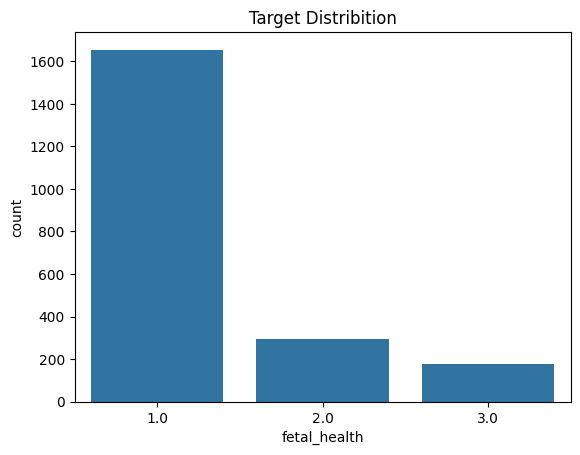

In [21]:
sns.countplot(x='fetal_health',data=df)
plt.title("Target Distribition")
plt.show()

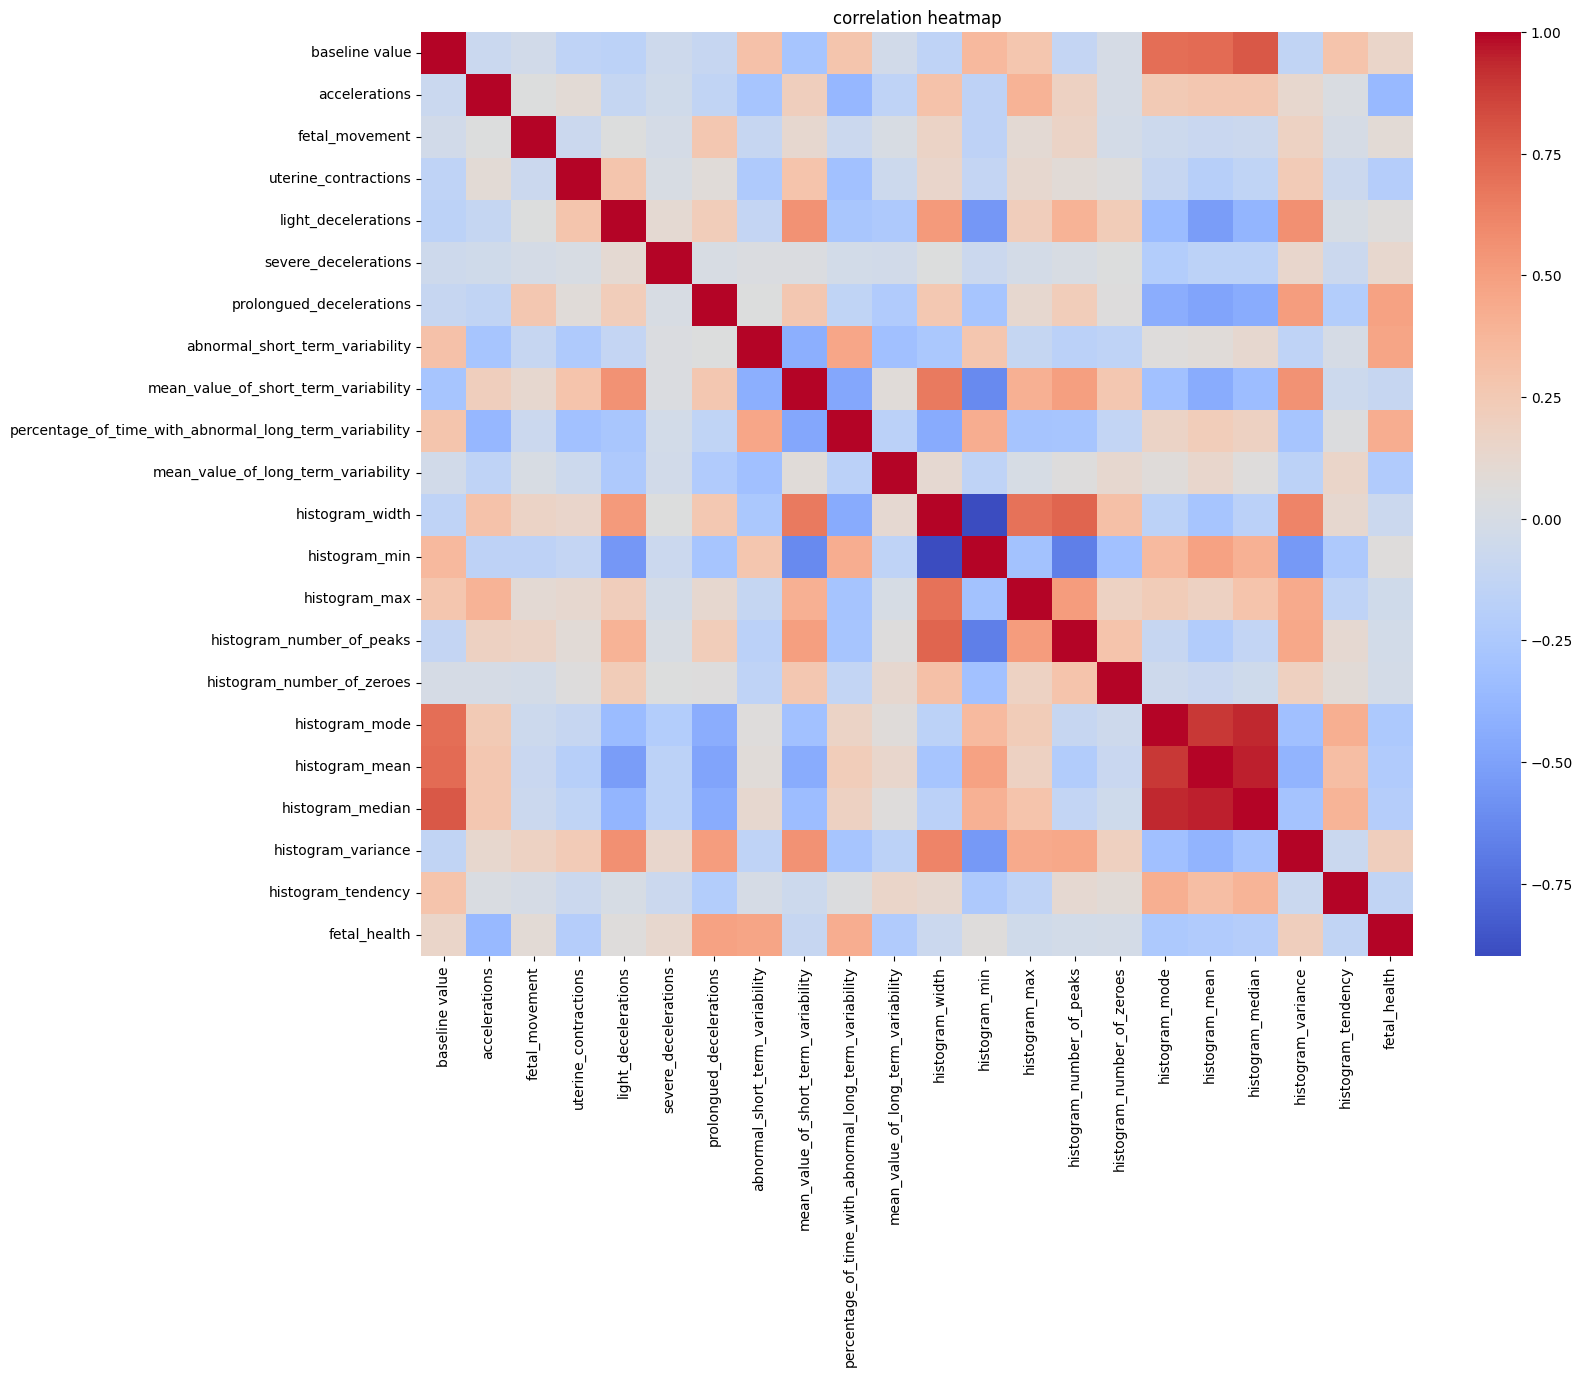

In [22]:
plt.figure(figsize=(16,12))
sns.heatmap(df.corr(),cmap='coolwarm')
plt.title("correlation heatmap")
plt.show()

In [25]:
x = df.drop('fetal_health',axis=1)
y= df['fetal_health']

In [26]:
x_train,x_test,y_train,y_test = train_test_split(
    x,y,test_size = 0.2, random_state = 42, stratify = y
)

In [28]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

FUNCTION FOR MODEL EVALUATION

In [29]:
def evaluate_model(model, X_train, X_test, y_train, y_test):

    start = time.time()

    model.fit(X_train, y_train)

    end = time.time()

    training_time = end - start

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average='weighted'
    )

    recall = recall_score(
        y_test,
        y_pred,
        average='weighted'
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average='weighted'
    )

    y_test_bin = label_binarize(y_test, classes=[1,2,3])

    roc_auc = roc_auc_score(
        y_test_bin,
        y_prob,
        multi_class='ovr'
    )

    return {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'ROC-AUC': roc_auc,
        'Training Time': training_time
    }

BASELINE MODELS

In [30]:
lr = LogisticRegression(max_iter = 500)

rf = RandomForestClassifier(random_state=42)

In [33]:
# Logistic Regression
lr_results = evaluate_model(
    lr,
    x_train_scaled,
    x_test_scaled,
    y_train,
    y_test
)

# Random Forest
rf_results = evaluate_model(
    rf,
    x_train,
    x_test,
    y_train,
    y_test
)

In [34]:
print(lr_results)

{'Accuracy': 0.8849765258215962, 'Precision': 0.8892931330942633, 'Recall': 0.8849765258215962, 'F1 Score': 0.88547065652584, 'ROC-AUC': 0.9613945194416479, 'Training Time': 0.06483125686645508}


In [35]:
print(rf_results)


{'Accuracy': 0.9248826291079812, 'Precision': 0.9217896679361778, 'Recall': 0.9248826291079812, 'F1 Score': 0.9219793629543472, 'ROC-AUC': 0.9786569990886989, 'Training Time': 0.5463190078735352}


# FEATURE SELECTION METHODS

In [ ]:
# 1. CORRELATION THRESHOLD

corr_matrix = x.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [
    column for column in upper.columns
    if any(upper[column] > 0.90)
]

X_corr = x.drop(columns=to_drop)

print("\nRemoved Features:", to_drop)


Removed Features: ['histogram_median']


In [40]:
# 2. ANOVA FEATURE SELECTION

anova_selector = SelectKBest(
    score_func=f_classif,
    k=10
)

X_anova = anova_selector.fit_transform(x, y)

selected_features_anova = x.columns[
    anova_selector.get_support()
]

print("\nANOVA Selected Features")
print(selected_features_anova)


ANOVA Selected Features
Index(['baseline value', 'accelerations', 'prolongued_decelerations',
       'abnormal_short_term_variability',
       'mean_value_of_short_term_variability',
       'percentage_of_time_with_abnormal_long_term_variability',
       'histogram_mode', 'histogram_mean', 'histogram_median',
       'histogram_variance'],
      dtype='str')


In [42]:
# 3. RFE

rfe_model = LogisticRegression(max_iter=500)

rfe = RFE(
    estimator=rfe_model,
    n_features_to_select=10
)

rfe.fit(x_train_scaled, y_train)

selected_features_rfe = x.columns[
    rfe.support_
]

print("\nRFE Selected Features")
print(selected_features_rfe)


RFE Selected Features
Index(['baseline value', 'accelerations', 'uterine_contractions',
       'prolongued_decelerations', 'abnormal_short_term_variability',
       'percentage_of_time_with_abnormal_long_term_variability',
       'histogram_mode', 'histogram_mean', 'histogram_median',
       'histogram_variance'],
      dtype='str')


In [45]:
# 4. RANDOM FOREST FEATURE IMPORTANCE

rf_fs = RandomForestClassifier(random_state=42)

rf_fs.fit(x_train, y_train)

importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': rf_fs.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

top_features = importance.head(10)['Feature']

print("\nTop Features")
print(top_features)


Top Features
8                  mean_value_of_short_term_variability
7                       abnormal_short_term_variability
9     percentage_of_time_with_abnormal_long_term_var...
17                                       histogram_mean
16                                       histogram_mode
6                              prolongued_decelerations
18                                     histogram_median
1                                         accelerations
10                  mean_value_of_long_term_variability
19                                   histogram_variance
Name: Feature, dtype: str


# SELECT FINAL FEATURES -  RFE




LOGISTIC REGRESSION WITH FS
{'Accuracy': 0.8967136150234741, 'Precision': 0.8972824401606773, 'Recall': 0.8967136150234741, 'F1 Score': 0.8961313008174471, 'ROC-AUC': 0.9595441672027883, 'Training Time': 0.04488730430603027}

RANDOM FOREST WITH FS
{'Accuracy': 0.9366197183098591, 'Precision': 0.9340390171244828, 'Recall': 0.9366197183098591, 'F1 Score': 0.9339424763040756, 'ROC-AUC': 0.9823709923364564, 'Training Time': 0.3807828426361084}
          Metric  LR Without FS  LR With FS  RF Without FS  RF With FS
0       Accuracy       0.884977    0.896714       0.924883    0.936620
1      Precision       0.889293    0.897282       0.921790    0.934039
2         Recall       0.884977    0.896714       0.924883    0.936620
3       F1 Score       0.885471    0.896131       0.921979    0.933942
4        ROC-AUC       0.961395    0.959544       0.978657    0.982371
5  Training Time       0.064831    0.044887       0.546319    0.380783


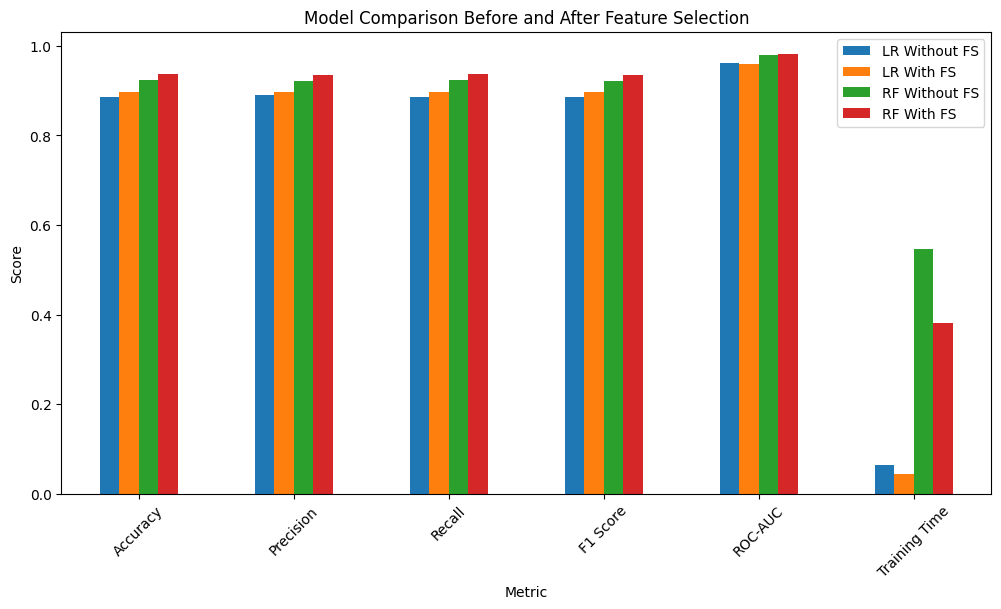

In [49]:
selected_features = list(selected_features_rfe)

X_selected = x[selected_features]

X_train_fs, X_test_fs, y_train_fs, y_test_fs = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train_fs_scaled = scaler.fit_transform(X_train_fs)
X_test_fs_scaled = scaler.transform(X_test_fs)

lr_fs_results = evaluate_model(
    lr,
    X_train_fs_scaled,
    X_test_fs_scaled,
    y_train_fs,
    y_test_fs
)

rf_fs_results = evaluate_model(
    rf,
    X_train_fs,
    X_test_fs,
    y_train_fs,
    y_test_fs
)

print("\nLOGISTIC REGRESSION WITH FS")
print(lr_fs_results)

print("\nRANDOM FOREST WITH FS")
print(rf_fs_results)

comparison = pd.DataFrame({

    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score',
        'ROC-AUC',
        'Training Time'
    ],

    'LR Without FS': [
        lr_results['Accuracy'],
        lr_results['Precision'],
        lr_results['Recall'],
        lr_results['F1 Score'],
        lr_results['ROC-AUC'],
        lr_results['Training Time']
    ],

    'LR With FS': [
        lr_fs_results['Accuracy'],
        lr_fs_results['Precision'],
        lr_fs_results['Recall'],
        lr_fs_results['F1 Score'],
        lr_fs_results['ROC-AUC'],
        lr_fs_results['Training Time']
    ],

    'RF Without FS': [
        rf_results['Accuracy'],
        rf_results['Precision'],
        rf_results['Recall'],
        rf_results['F1 Score'],
        rf_results['ROC-AUC'],
        rf_results['Training Time']
    ],

    'RF With FS': [
        rf_fs_results['Accuracy'],
        rf_fs_results['Precision'],
        rf_fs_results['Recall'],
        rf_fs_results['F1 Score'],
        rf_fs_results['ROC-AUC'],
        rf_fs_results['Training Time']
    ]
})

print(comparison)

# ==========================================
# VISUALIZATION
# ==========================================

comparison.set_index('Metric').plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Model Comparison Before and After Feature Selection")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()


LOGISTIC REGRESSION WITH FS
{'Accuracy': 0.8849765258215962, 'Precision': 0.8841778000677988, 'Recall': 0.8849765258215962, 'F1 Score': 0.8841449293669341, 'ROC-AUC': 0.9563875517007953, 'Training Time': 0.038514137268066406}

RANDOM FOREST WITH FS
{'Accuracy': 0.9272300469483568, 'Precision': 0.9251653717261317, 'Recall': 0.9272300469483568, 'F1 Score': 0.9239898077926247, 'ROC-AUC': 0.9768465203991145, 'Training Time': 0.43610191345214844}
          Metric  LR Without FS  LR With FS  RF Without FS  RF With FS
0       Accuracy       0.884977    0.884977       0.924883    0.927230
1      Precision       0.889293    0.884178       0.921790    0.925165
2         Recall       0.884977    0.884977       0.924883    0.927230
3       F1 Score       0.885471    0.884145       0.921979    0.923990
4        ROC-AUC       0.961395    0.956388       0.978657    0.976847
5  Training Time       0.064831    0.038514       0.546319    0.436102


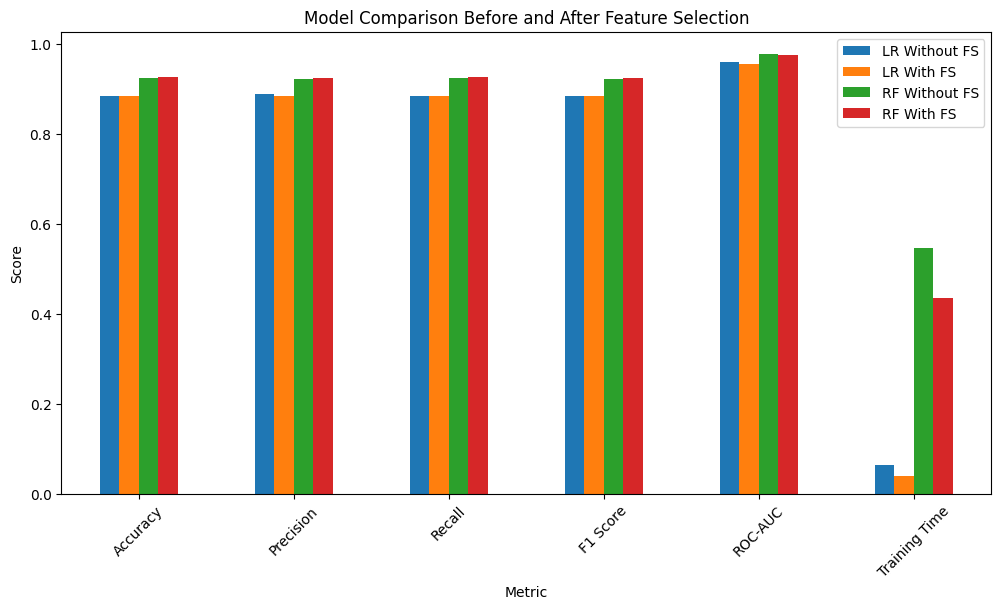

In [50]:
# SELECT FINAL FEATURES -  ANOVA FEATURE SELECTION

selected_features = list(selected_features_anova)

X_selected = x[selected_features]

X_train_fs, X_test_fs, y_train_fs, y_test_fs = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train_fs_scaled = scaler.fit_transform(X_train_fs)
X_test_fs_scaled = scaler.transform(X_test_fs)

lr_fs_results = evaluate_model(
    lr,
    X_train_fs_scaled,
    X_test_fs_scaled,
    y_train_fs,
    y_test_fs
)

rf_fs_results = evaluate_model(
    rf,
    X_train_fs,
    X_test_fs,
    y_train_fs,
    y_test_fs
)

print("\nLOGISTIC REGRESSION WITH FS")
print(lr_fs_results)

print("\nRANDOM FOREST WITH FS")
print(rf_fs_results)

comparison = pd.DataFrame({

    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score',
        'ROC-AUC',
        'Training Time'
    ],

    'LR Without FS': [
        lr_results['Accuracy'],
        lr_results['Precision'],
        lr_results['Recall'],
        lr_results['F1 Score'],
        lr_results['ROC-AUC'],
        lr_results['Training Time']
    ],

    'LR With FS': [
        lr_fs_results['Accuracy'],
        lr_fs_results['Precision'],
        lr_fs_results['Recall'],
        lr_fs_results['F1 Score'],
        lr_fs_results['ROC-AUC'],
        lr_fs_results['Training Time']
    ],

    'RF Without FS': [
        rf_results['Accuracy'],
        rf_results['Precision'],
        rf_results['Recall'],
        rf_results['F1 Score'],
        rf_results['ROC-AUC'],
        rf_results['Training Time']
    ],

    'RF With FS': [
        rf_fs_results['Accuracy'],
        rf_fs_results['Precision'],
        rf_fs_results['Recall'],
        rf_fs_results['F1 Score'],
        rf_fs_results['ROC-AUC'],
        rf_fs_results['Training Time']
    ]
})

print(comparison)

# ==========================================
# VISUALIZATION
# ==========================================

comparison.set_index('Metric').plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Model Comparison Before and After Feature Selection")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()


To check overfitting/Underfitting

In [51]:
# ==========================================
# FUNCTION TO CHECK OVERFITTING
# ==========================================

def check_overfitting(model, X_train, X_test, y_train, y_test):

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    # Accuracy
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    print("\nTraining Accuracy:", train_acc)
    print("Testing Accuracy:", test_acc)

    difference = train_acc - test_acc

    print("Difference:", difference)

    # Interpretation
    if difference > 0.10:
        print("Model is likely OVERFITTING")

    elif train_acc < 0.75 and test_acc < 0.75:
        print("Model is likely UNDERFITTING")

    else:
        print("Model is WELL GENERALIZED")

In [54]:
check_overfitting(
    lr,
    x_train_scaled,
    x_test_scaled,
    y_train,
    y_test
)


Training Accuracy: 0.9035294117647059
Testing Accuracy: 0.8849765258215962
Difference: 0.018552885943109665
Model is WELL GENERALIZED


In [55]:
check_overfitting(
    rf,
    x_train,
    x_test,
    y_train,
    y_test
)


Training Accuracy: 0.9994117647058823
Testing Accuracy: 0.9248826291079812
Difference: 0.07452913559790109
Model is WELL GENERALIZED
